In [5]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# KONFIGURASI BERKAS INPUT
# ==========================================

INPUT_PATH = 'lda_negative_results.csv'

if not os.path.exists(INPUT_PATH):

    print(f"[ERROR] Berkas tidak ditemukan di: {INPUT_PATH}")
    print("Pastikan model final LDA sudah dijalankan.")

else:

    print("Memuat data hasil LDA (sentimen negatif)...")

    # ==========================================
    # MEMBACA DATA
    # ==========================================

    df_lda = pd.read_csv(INPUT_PATH)

    # Konversi timestamp ke datetime
    df_lda['timestamp'] = pd.to_datetime(df_lda['timestamp'])

    # Mengambil komponen tahun
    df_lda['year'] = df_lda['timestamp'].dt.year

    # Mendapatkan daftar tahun unik
    unique_years = sorted(df_lda['year'].unique())

    # ==========================================
    # LABEL DAN WARNA TOPIK
    # ==========================================

    topic_colors = [
        '#4f6d7a',
        '#c0d6df',
        '#b85d53',
        '#eaaf9b',
        '#6f5060',
        '#a3b18a'
    ]

    topic_labels = [
        "Topik 1: Pembahasan Kebijakan, Komisi, dan Sidang DPR",
        "Topik 2: Kritik terhadap Kebijakan dan Representasi Wakil Rakyat",
        "Topik 3: Kritik terhadap Politik Partai dan Proses Legislasi DPR",
        "Topik 4: Reses dan Aktivitas Kelembagaan DPR",
        "Topik 5: Aspirasi Rakyat dan Fungsi Perwakilan DPR",
        "Topik 6: Korupsi dan Kritik terhadap Elite Politik"
    ]

    print(f"Daftar tahun yang ditemukan: {unique_years}")
    print("Memulai pembuatan visualisasi bar chart tahunan...")

    # ==========================================
    # ITERASI VISUALISASI PER TAHUN
    # ==========================================

    for target_year in unique_years:

        # Filter data per tahun
        df_year = df_lda[df_lda['year'] == target_year]

        # Hitung frekuensi tiap topik
        topic_counts = df_year['dominant_topic'].value_counts()

        # Mengunci urutan topik 1-6
        counts = [topic_counts.get(i, 0) for i in range(1, 7)]

        # Skip jika kosong
        if sum(counts) == 0:
            continue

        # Mengubah ke persentase
        total = sum(counts)

        percentages = [
            (count / total) * 100
            for count in counts
        ]

        # ==========================================
        # MEMBUAT BAR CHART
        # ==========================================

        fig, ax = plt.subplots(figsize=(10, 6))

        bars = ax.bar(
            x=[f'T{i}' for i in range(1, 7)],
            height=percentages,
            color=topic_colors,
            edgecolor='white',
            linewidth=1.2
        )

        # ==========================================
        # MENAMBAHKAN LABEL PERSENTASE
        # ==========================================

        for bar, pct in zip(bars, percentages):

            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 1,
                f'{pct:.1f}%',
                ha='center',
                va='bottom',
                fontsize=9,
                fontweight='bold'
            )

        # ==========================================
        # JUDUL DAN LABEL
        # ==========================================

        ax.set_title(
            f'Distribusi Topik LDA Sentimen Negatif DPR Tahun {target_year}',
            fontsize=13,
            fontweight='bold',
            pad=15
        )

        ax.set_xlabel(
            'Klaster Topik',
            fontsize=11,
            fontweight='bold'
        )

        ax.set_ylabel(
            'Persentase Topik (%)',
            fontsize=11,
            fontweight='bold'
        )

        # ==========================================
        # GRID DAN BATAS Y
        # ==========================================

        ax.grid(
            axis='y',
            linestyle='--',
            alpha=0.3
        )

        ax.set_ylim(0, max(percentages) + 10)

        # ==========================================
        # LEGENDA
        # ==========================================

        ax.legend(
            bars,
            topic_labels,
            title='Keterangan Klaster Isu',
            loc='upper center',
            bbox_to_anchor=(0.5, -0.15),
            ncol=2,
            fontsize=8.5,
            frameon=True
        )

        # ==========================================
        # MERAPIKAN LAYOUT
        # ==========================================

        plt.tight_layout()

        # ==========================================
        # MENYIMPAN GAMBAR
        # ==========================================

        filename = f'barchart_topik_tahun_{target_year}.png'

        plt.savefig(
            filename,
            dpi=300,
            bbox_inches='tight'
        )

        plt.close()

        print(
            f" -> Berhasil menyimpan: {filename} "
            f"(Total data negatif: {total})"
        )

    print(
        "\n[SUKSES TOTAL] "
        "Seluruh visualisasi bar chart tahunan berhasil disimpan!"
    )

Memuat data hasil LDA (sentimen negatif)...
Daftar tahun yang ditemukan: [np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025)]
Memulai pembuatan visualisasi bar chart tahunan...
 -> Berhasil menyimpan: barchart_topik_tahun_2016.png (Total data negatif: 1203)
 -> Berhasil menyimpan: barchart_topik_tahun_2017.png (Total data negatif: 1349)
 -> Berhasil menyimpan: barchart_topik_tahun_2018.png (Total data negatif: 857)
 -> Berhasil menyimpan: barchart_topik_tahun_2019.png (Total data negatif: 123)
 -> Berhasil menyimpan: barchart_topik_tahun_2020.png (Total data negatif: 196)
 -> Berhasil menyimpan: barchart_topik_tahun_2021.png (Total data negatif: 264)
 -> Berhasil menyimpan: barchart_topik_tahun_2022.png (Total data negatif: 10)
 -> Berhasil menyimpan: barchart_topik_tahun_2023.png (Total data negatif: 26)
 -> Berhasil menyimpan: barchart_topik_tahun_2024.png (Total data negatif: 

Memuat data hasil LDA...


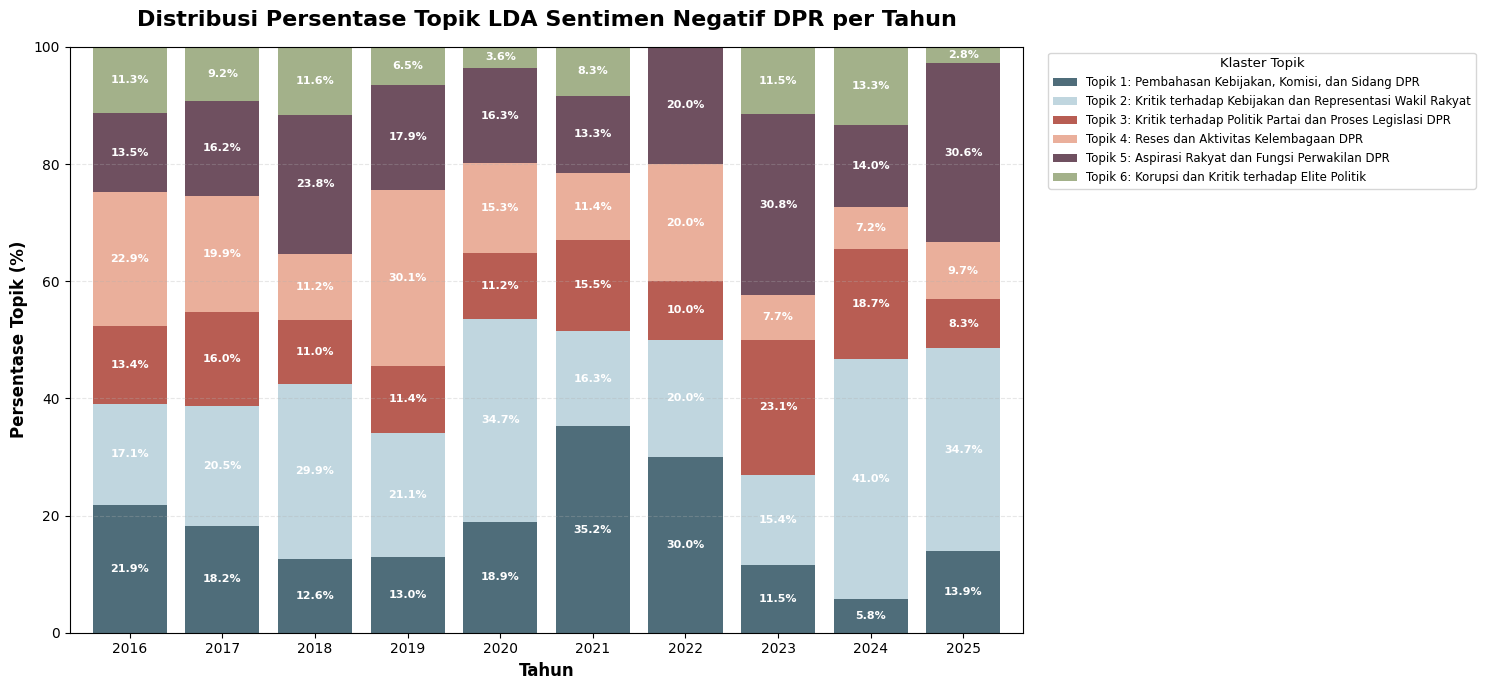


[SUKSES] Visualisasi berhasil disimpan:
-> stacked_topic_distribution_per_year.png


In [4]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# KONFIGURASI BERKAS INPUT
# ==========================================

INPUT_PATH = 'lda_negative_results.csv'

if not os.path.exists(INPUT_PATH):
    print(f"[ERROR] Berkas tidak ditemukan di: {INPUT_PATH}")
    print("Pastikan hasil final LDA sudah tersedia.")
    
else:
    print("Memuat data hasil LDA...")

    # Membaca data
    df_lda = pd.read_csv(INPUT_PATH)

    # ==========================================
    # PREPROCESSING TAHUN
    # ==========================================

    # Konversi timestamp ke datetime
    df_lda['timestamp'] = pd.to_datetime(df_lda['timestamp'])

    # Ambil tahun
    df_lda['year'] = df_lda['timestamp'].dt.year

    # ==========================================
    # DISTRIBUSI TOPIK PER TAHUN
    # ==========================================

    topic_distribution = pd.crosstab(
        df_lda['year'],
        df_lda['dominant_topic']
    )

    # Mengunci urutan topik 1-6
    topic_distribution = topic_distribution.reindex(
        columns=[1, 2, 3, 4, 5, 6],
        fill_value=0
    )

    # Konversi ke persentase
    topic_percentage = topic_distribution.div(
        topic_distribution.sum(axis=1),
        axis=0
    ) * 100

    # ==========================================
    # LABEL DAN WARNA TOPIK
    # ==========================================

    topic_labels = [
        "Topik 1: Pembahasan Kebijakan, Komisi, dan Sidang DPR",
        "Topik 2: Kritik terhadap Kebijakan dan Representasi Wakil Rakyat",
        "Topik 3: Kritik terhadap Politik Partai dan Proses Legislasi DPR",
        "Topik 4: Reses dan Aktivitas Kelembagaan DPR",
        "Topik 5: Aspirasi Rakyat dan Fungsi Perwakilan DPR",
        "Topik 6: Korupsi dan Kritik terhadap Elite Politik"
    ]

    # Warna formal akademik (muted)
    topic_colors = [
        '#4f6d7a',
        '#c0d6df',
        '#b85d53',
        '#eaaf9b',
        '#6f5060',
        '#a3b18a'
    ]

    # Mengganti nama kolom
    topic_percentage.columns = topic_labels

    # ==========================================
    # MEMBUAT 100% STACKED BAR CHART
    # ==========================================

    fig, ax = plt.subplots(figsize=(15, 7))

    topic_percentage.plot(
        kind='bar',
        stacked=True,
        color=topic_colors,
        ax=ax,
        width=0.8
    )

    # ==========================================
    # MENAMBAHKAN LABEL PERSENTASE
    # ==========================================

    for container in ax.containers:

        labels = []

        for bar in container:

            height = bar.get_height()

            # Tampilkan label jika > 2%
            if height > 2:
                labels.append(f'{height:.1f}%')
            else:
                labels.append('')

        ax.bar_label(
            container,
            labels=labels,
            label_type='center',
            fontsize=8,
            fontweight='bold',
            color='white'
        )

    # ==========================================
    # PENGATURAN JUDUL DAN LABEL
    # ==========================================

    ax.set_title(
        'Distribusi Persentase Topik LDA Sentimen Negatif DPR per Tahun',
        fontsize=16,
        fontweight='bold',
        pad=15
    )

    ax.set_xlabel(
        'Tahun',
        fontsize=12,
        fontweight='bold'
    )

    ax.set_ylabel(
        'Persentase Topik (%)',
        fontsize=12,
        fontweight='bold'
    )

    # Rotasi label tahun
    plt.xticks(rotation=0)

    # Grid horizontal
    ax.grid(
        axis='y',
        linestyle='--',
        alpha=0.3
    )

    # ==========================================
    # LEGEND
    # ==========================================

    ax.legend(
        title='Klaster Topik',
        bbox_to_anchor=(1.02, 1),
        loc='upper left',
        fontsize=8.5,
        title_fontsize=9.5,
        frameon=True
    )

    # ==========================================
    # MEMPERBESAR ANGKA Y
    # ==========================================

    ax.tick_params(axis='y', labelsize=10)

    # ==========================================
    # MERAPIKAN LAYOUT
    # ==========================================

    plt.tight_layout()

    # ==========================================
    # MENYIMPAN GAMBAR
    # ==========================================

    OUTPUT_FILENAME = 'stacked_topic_distribution_per_year.png'

    plt.savefig(
        OUTPUT_FILENAME,
        dpi=300,
        bbox_inches='tight'
    )

    # ==========================================
    # MENAMPILKAN VISUALISASI
    # ==========================================

    plt.show()

    print("\n[SUKSES] Visualisasi berhasil disimpan:")
    print(f"-> {OUTPUT_FILENAME}")